In [2]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_10_natural = get_prompt("natural", 10)

prompt_10_natural

'Simulate 1LYZ for 1ps at 300 K and for 1ps at 400K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute RMSD and radius of gyration of both simulations. Compute SASA for the 300K simulation.'

In [3]:
llm_model = "gpt-4o-2024-08-06"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_10_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: To address the question, I need to perform several tasks: download the PDB file for 1LYZ, set up and run simulations at 300 K and 400 K, compute secondary structure assignments, identify binding or active sites, compute RMSD and radius of gyration for both simulations, and compute SASA for the 300 K simulation. I will start by downloading the PDB file for 1LYZ.

Action:
```
{
  "action": "PDBFileDownloader",
  "action_input": "1LYZ"
}
```

PDB file found with this ID: 1LYZ



Observation: Succeeded. Downloaded the PDB file:1LYZ_201345
Thought:

To proceed, I need to set up and run the simulations for 1LYZ at 300 K and 400 K. After that, I will compute the secondary structure assignments, identify binding or active sites, compute RMSD and radius of gyration for both simulations, and compute SASA for the 300 K simulation.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_201345",
    "forcefield_files": ["amber99sb.xml", "tip3p.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1.0 * nanometers",
      "ewaldErrorTolerance": "0.0005",
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": "0.00001",
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NPT",
     

...

To complete the task, I need to compute the Solvent Accessible Surface Area (SASA) for the 300 K simulation. Let's proceed with this computation.

Action:
```json
{
  "action": "SolventAccessibleSurfaceArea",
  "action_input": {
    "top_fileid": "top_sim0_201401",
    "traj_fileid": "rec0_201406",
    "molecule_name": "1LYZ"
  }
}
```Loading trajectory ...


Calculating SASA ...
Data saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_0/records/sasa_1LYZ.csv


SASA plot saved to FIG_sasa_1LYZ_20251222_210413.png

Observation: Succeeded. SASA values computed and saved with File ID sasa_1LYZ. SASA analysis completed. Saved the plot with plot ID fig0_210413. 
Thought:

Action:
```json
{
  "action": "Final Answer",
  "action_input": "The simulation and analysis for 1LYZ have been completed as follows:\n\n1. **Secondary Structure Assignments**: \n   - Helix: 50 residues\n   - Strand: 14 residues\n   - Coil: 65 residues\n   - Not assigned: 101 residues (not protein residues)\n\n2. **Known Sites**:\n   - Active Sites: Residues 53 and 71\n   - No known binding sites or other relevant sites.\n\n3. **RMSD and Radius of Gyration**:\n   - **300 K Simulation**:\n     - RMSD: Results saved in file ID rmsd_201401\n     - Radius of Gyration: Average 3.41 nm (Plot ID: fig0_204159)\n   - **400 K Simulation**:\n     - RMSD: Results saved in file ID rmsd_202650\n     - Radius of Gyration: Average 3.45 nm (Plot ID: fig0_204206)\n\n4. **Solvent Accessible Surface Area (SASA) for 300 K Simulation**:\n   - SASA values computed and saved with File ID sasa_1LYZ (Plot ID: fig0_210413)\n\nAll computations and analyses have been successfully completed."
}
```

> Finished chai

<Figure size 640x480 with 0 Axes>

In [4]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_201345: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_201345
 1LYZ_201356: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_201401: Initial positions for simulation sim0_201401
 sim0_201401: Basic Simulation of Protein 1LYZ_201356
 rec0_201406: Simulation trajectory for protein 1LYZ_201356 and simulation sim0_201401
 rec1_201406: Simulation state log for protein 1LYZ_201356 and simulation sim0_201401
 rec2_201406: Simulation pdb frames for protein 1LYZ_201356 and simulation sim0_201401
 top_sim0_202650: Initial positions for simulation sim0_202650
 sim0_202650: Basic Simulation of Protein 1LYZ_201356
 rec0_202655: Simulation trajectory for protein 1LYZ_201356 and simulation sim0_202650
 rec1_202655: Simulation state log for protein 1LYZ_201356 and simulation sim0_202650
 rec2_202655: Simulation pdb frames for protein 1LYZ_2013

In [5]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_201345"))

In [6]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_201345", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [7]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [9]:
# make sure trajectory and topology exist
traj_path_1 = registry.get_mapped_path("rec0_201406")
top_path_1 = registry.get_mapped_path("top_sim0_201401")

assert os.path.exists(traj_path_1)
assert os.path.exists(top_path_1)

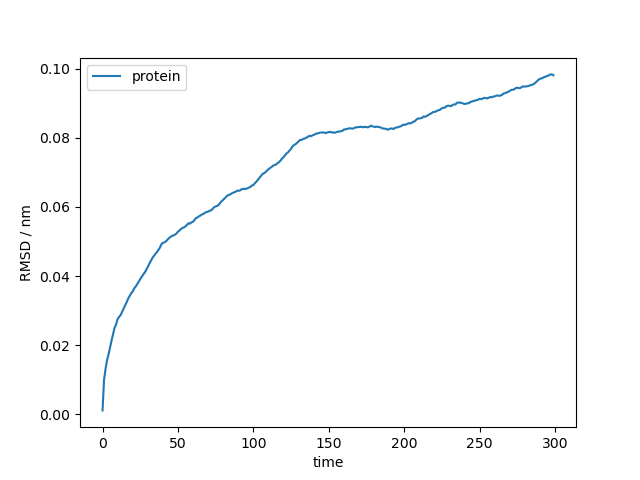

In [10]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_204155'))

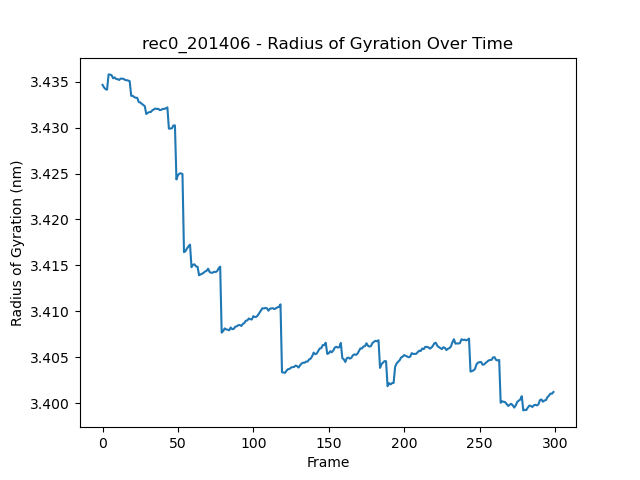

In [12]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_204159'))

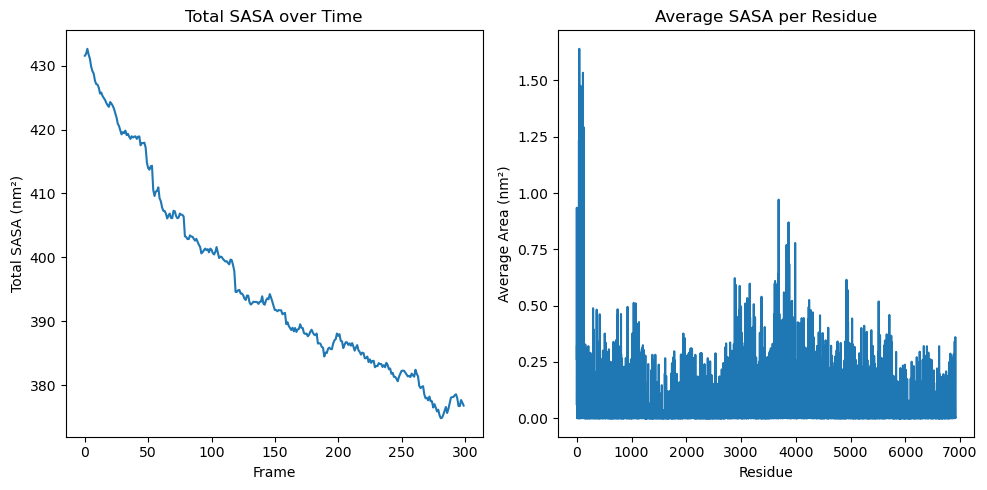

In [14]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_210413'))

In [15]:
# make sure trajectory and topology exist (sim2)
traj_path_2 = registry.get_mapped_path("rec0_202655")
top_path_2 = registry.get_mapped_path("top_sim0_202650")

assert os.path.exists(traj_path_2)
assert os.path.exists(top_path_2)

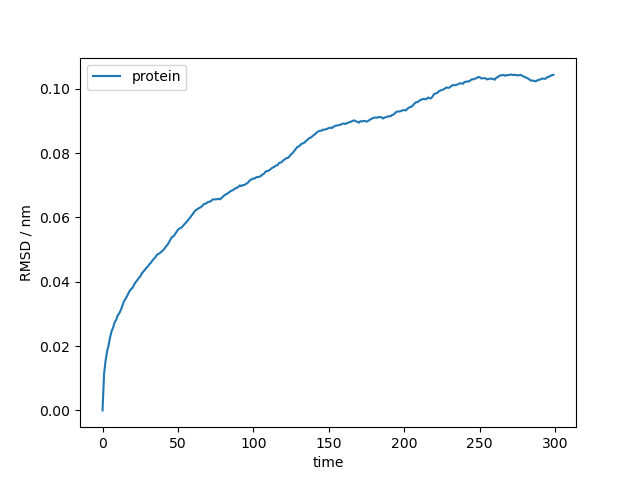

In [11]:
# make sure rmsd plot was generated (sim2)
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_204202'))

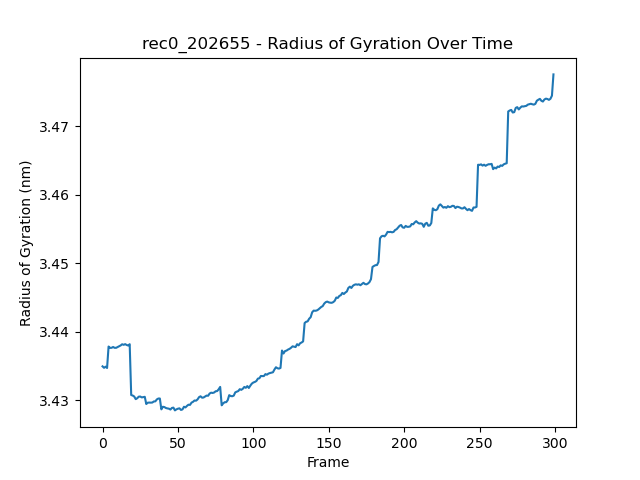

In [13]:
# make sure rgy plot was generated (sim2)
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_204206'))

In [16]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 122974
Output tokens: 2312
LLM costs: $ 0.330555
